LOADING EV MASTER DATASET

Shape:
(1905, 36)

Columns:
['month', 'state_name', 'ev_registrations', '2w_registrations', '3w_registrations', '4w_registrations', 'goods_registrations', 'other_registrations', 'bus_registrations', 'maker_bajaj_auto_ltd', 'maker_hero_motocorp_ltd', 'maker_honda_motorcycle_and_scooter_india_p_ltd', 'maker_hyundai_motor_india_ltd', 'maker_india_yamaha_motor_pvt_ltd', 'maker_mahindra_mahindra_limited', 'maker_maruti_suzuki_india_ltd', 'maker_royal_enfield_unit_of_eicher_ltd', 'maker_suzuki_motorcycle_india_pvt_ltd', 'maker_tvs_motor_company_ltd', 'category_total', '2w_share', '3w_share', '4w_share', 'ev_growth', 'ev_growth_3m', 'ev_growth_12m', 'ev_lag_1', 'ev_lag_3', 'ev_lag_6', 'ev_lag_12', 'ev_rolling_3', 'ev_rolling_6', 'ev_rolling_12', 'year', 'month_number', 'quarter']

First 5 rows:
        month                   state_name  ev_registrations  \
0  2019-05-01  ANDAMAN AND NICOBAR ISLANDS               2.0   
1  2020-02-01  ANDAMAN AND NICOBAR ISLANDS    

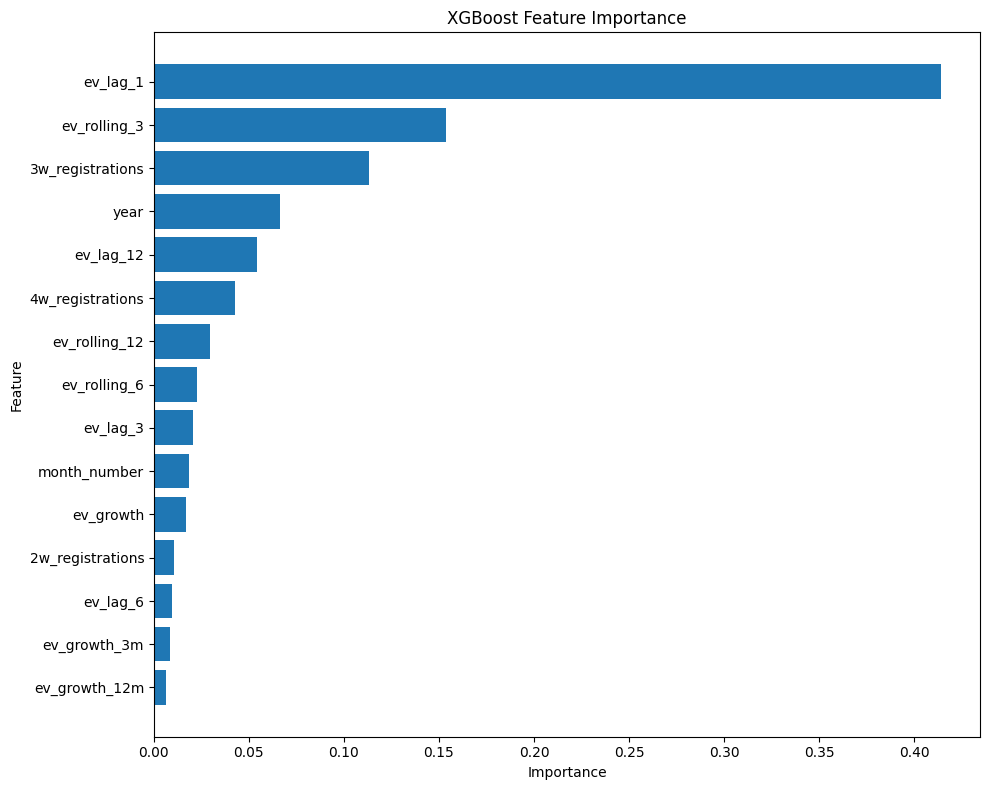

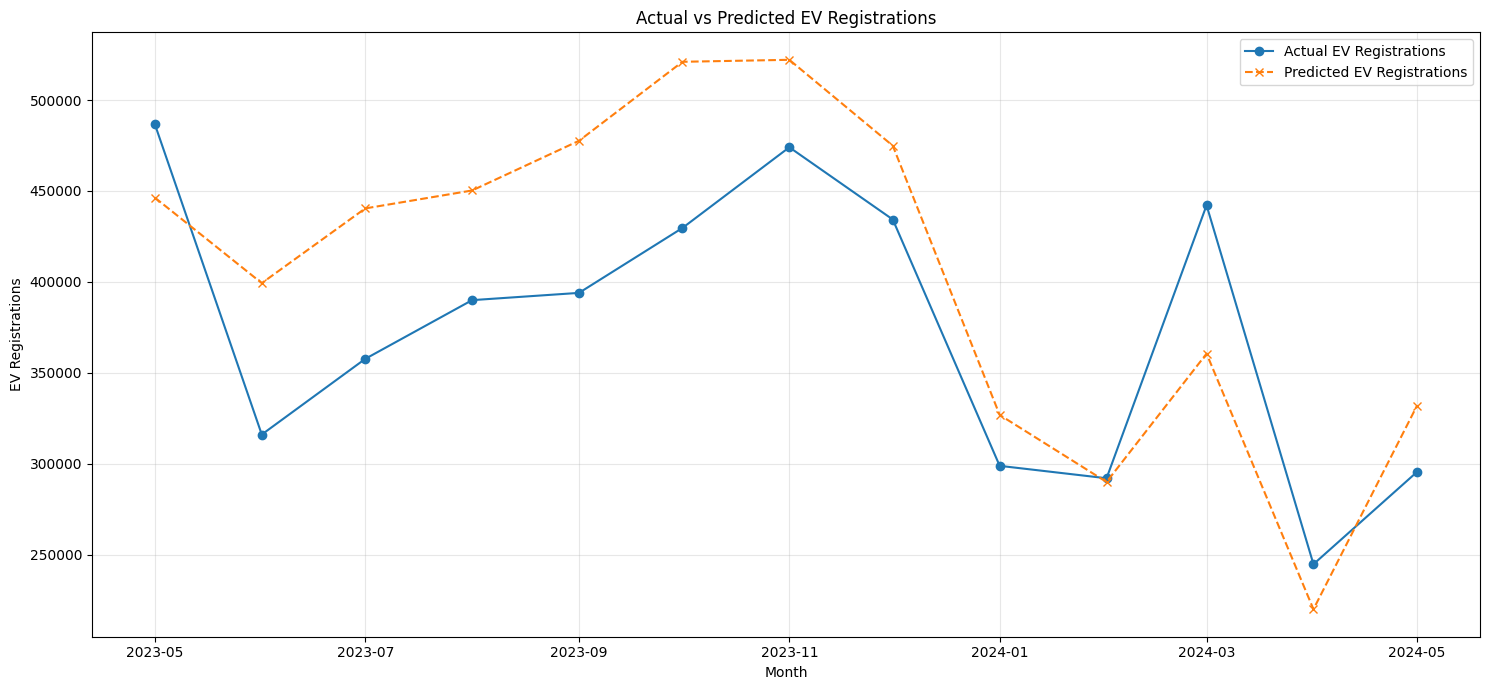


Model saved:
models/ev_demand_xgboost.pkl

CREATING FUTURE EV DEMAND FORECAST

Forecast saved:
outputs/future_ev_demand_forecast.csv

NEXT 12 MONTHS EV FORECAST
        month    forecast_ev
0  2024-06-01  330099.002586
1  2024-07-01  333145.759918
2  2024-08-01  346979.316298
3  2024-09-01  366784.814626
4  2024-10-01  366398.756455
5  2024-11-01  363964.267654
6  2024-12-01  357840.948120
7  2025-01-01  350848.012177
8  2025-02-01  344822.918152
9  2025-03-01  344690.635019
10 2025-04-01  346701.026260
11 2025-05-01  350029.581109


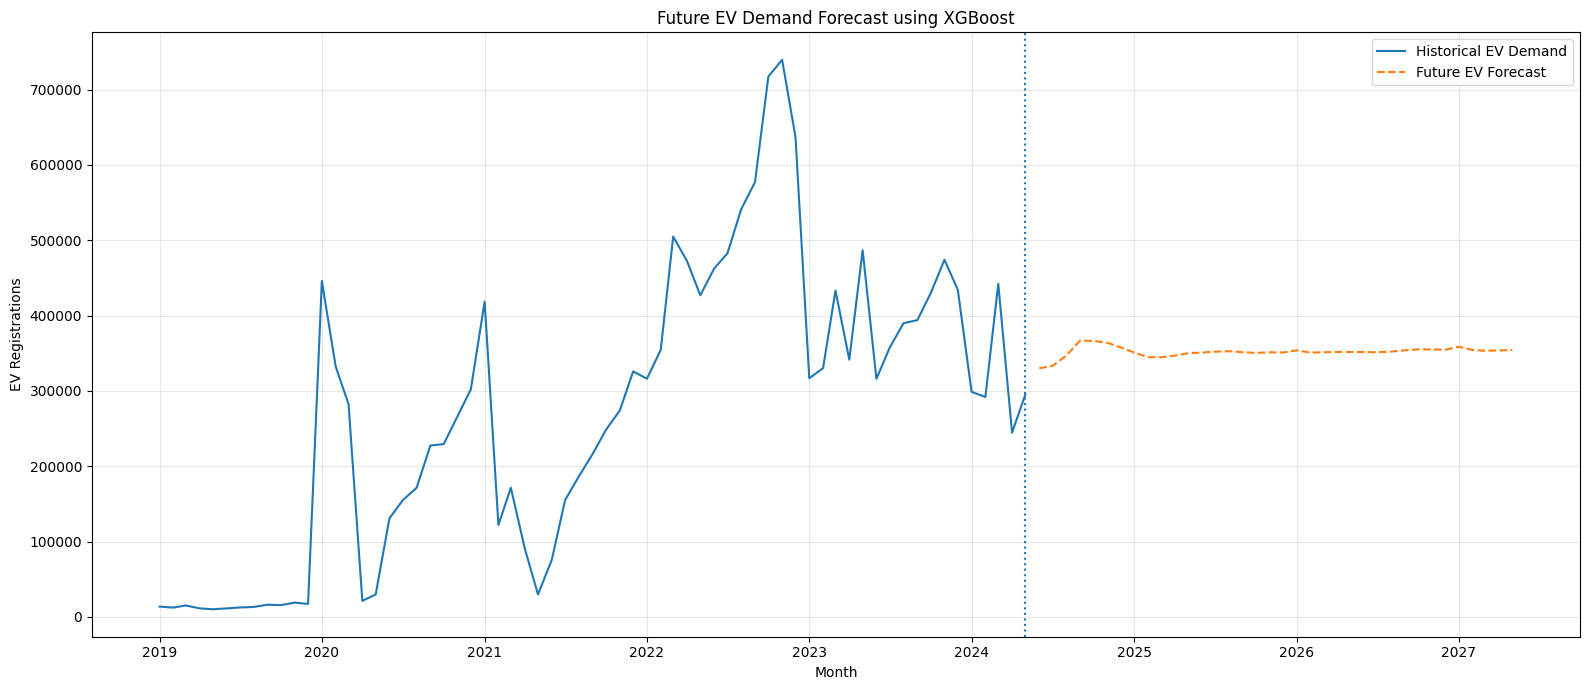


FORECAST SUMMARY
Latest actual monthly EV registrations: 295,388
12-month forecast: 350,030
12-month growth: 18.50%
36-month forecast: 354,179
36-month growth: 19.90%

EV FORECASTING PIPELINE COMPLETED

Generated:

models/
    ev_demand_xgboost.pkl
    ev_feature_medians.pkl
    ev_feature_names.pkl

outputs/
    ev_test_predictions.csv
    ev_feature_importance.csv
    ev_feature_importance.png
    actual_vs_predicted_ev.png
    future_ev_demand_forecast.csv
    future_ev_demand_forecast.png



In [2]:
# ============================================================
# EV DEMAND FORECASTING
# EV MASTER DATASET -> XGBOOST REGRESSOR
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

DATA_FILE = (
    "/content/data/processed/ev_master_dataset.csv"
)

MODEL_DIR = "models"
OUTPUT_DIR = "outputs"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Number of months to forecast
FORECAST_MONTHS = 36


# ============================================================
# 2. LOAD DATA
# ============================================================

print("=" * 70)
print("LOADING EV MASTER DATASET")
print("=" * 70)

df = pd.read_csv(DATA_FILE)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. BASIC CLEANING
# ============================================================

print("\n" + "=" * 70)
print("CLEANING DATA")
print("=" * 70)

# Convert month
df["month"] = pd.to_datetime(
    df["month"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(
    subset=["month"]
)

# Make sure target is numeric
df["ev_registrations"] = pd.to_numeric(
    df["ev_registrations"],
    errors="coerce"
)

df = df.dropna(
    subset=["ev_registrations"]
)

# State
df["state_name"] = (
    df["state_name"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. SORT DATA
# ============================================================

df = df.sort_values(
    [
        "state_name",
        "month"
    ]
).reset_index(drop=True)


print("\nDate range:")

print(
    df["month"].min(),
    "to",
    df["month"].max()
)

print(
    "\nNumber of states:",
    df["state_name"].nunique()
)


# ============================================================
# 5. REMOVE INFINITE VALUES
# ============================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 6. SELECT FEATURES
# ============================================================

candidate_features = [

    # Time
    "year",
    "month_number",
    "quarter",

    # Current category information
    "2w_registrations",
    "3w_registrations",
    "4w_registrations",
    "bus_registrations",

    # Category shares
    "2w_share",
    "3w_share",
    "4w_share",

    # EV growth
    "ev_growth",
    "ev_growth_3m",
    "ev_growth_12m",

    # EV lag features
    "ev_lag_1",
    "ev_lag_3",
    "ev_lag_6",
    "ev_lag_12",

    # Rolling features
    "ev_rolling_3",
    "ev_rolling_6",
    "ev_rolling_12"
]


# Keep only features that actually exist
features = [
    col
    for col in candidate_features
    if col in df.columns
]


print("\nFeatures used by XGBoost:")

for feature in features:
    print(" -", feature)


# ============================================================
# 7. HANDLE MISSING VALUES
# ============================================================

# IMPORTANT:
# Do NOT fill missing lag values with future information.
# Median is calculated from training data later.

print("\nMissing values before processing:")

print(
    df[features].isnull().sum()
)


# ============================================================
# 8. CREATE TIME-BASED TRAIN/TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 70)

# Use the last 20% of dates for testing
unique_dates = sorted(
    df["month"].unique()
)

split_position = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[
    split_position
]


train_df = df[
    df["month"] < split_date
].copy()


test_df = df[
    df["month"] >= split_date
].copy()


print(
    "Training period:",
    train_df["month"].min(),
    "to",
    train_df["month"].max()
)

print(
    "Testing period:",
    test_df["month"].min(),
    "to",
    test_df["month"].max()
)

print(
    "\nTraining rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)


# ============================================================
# 9. TARGET
# ============================================================

TARGET = "ev_registrations"


X_train = train_df[features].copy()

y_train = train_df[TARGET].copy()

X_test = test_df[features].copy()

y_test = test_df[TARGET].copy()


# ============================================================
# 10. FILL MISSING VALUES
# ============================================================

# Calculate medians ONLY from training data
# to avoid data leakage.

train_medians = X_train.median(
    numeric_only=True
)

X_train = X_train.fillna(
    train_medians
)

X_test = X_test.fillna(
    train_medians
)


# ============================================================
# 11. TRAIN XGBOOST
# ============================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST REGRESSOR")
print("=" * 70)


model = XGBRegressor(

    n_estimators=600,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.1,

    reg_lambda=1.0,

    objective="reg:squarederror",

    eval_metric="rmse",

    random_state=42,

    n_jobs=-1

)


model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],

    verbose=False
)


print(
    "XGBoost training completed."
)


# ============================================================
# 12. PREDICTION
# ============================================================

y_pred = model.predict(
    X_test
)

# Prevent negative predictions
y_pred = np.maximum(
    y_pred,
    0
)


# ============================================================
# 13. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


# MAPE
non_zero = y_test != 0

if non_zero.sum() > 0:

    mape = np.mean(
        np.abs(
            (
                y_test[non_zero]
                -
                y_pred[non_zero]
            )
            /
            y_test[non_zero]
        )
    ) * 100

else:

    mape = np.nan


print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    f"MAE  : {mae:,.2f}"
)

print(
    f"RMSE : {rmse:,.2f}"
)

print(
    f"R²   : {r2:.4f}"
)

print(
    f"MAPE : {mape:.2f}%"
)


# ============================================================
# 14. SAVE TEST PREDICTIONS
# ============================================================

test_results = test_df[
    [
        "month",
        "state_name",
        "ev_registrations"
    ]
].copy()


test_results["predicted_ev"] = y_pred


test_results["error"] = (
    test_results["ev_registrations"]
    -
    test_results["predicted_ev"]
)


test_results["absolute_error"] = (
    np.abs(
        test_results["error"]
    )
)


TEST_OUTPUT = (
    f"{OUTPUT_DIR}/"
    "ev_test_predictions.csv"
)


test_results.to_csv(
    TEST_OUTPUT,
    index=False
)


print(
    "\nTest predictions saved:"
)

print(
    TEST_OUTPUT
)


# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "feature":
        features,

    "importance":
        model.feature_importances_

})


importance = importance.sort_values(
    "importance",
    ascending=False
)


print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance
)


importance.to_csv(
    f"{OUTPUT_DIR}/"
    "ev_feature_importance.csv",
    index=False
)


# ============================================================
# 16. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plot_data = importance.head(15)

plt.barh(
    plot_data["feature"][::-1],
    plot_data["importance"][::-1]
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "ev_feature_importance.png",
    dpi=300
)

plt.show()


# ============================================================
# 17. ACTUAL VS PREDICTED
# ============================================================

# Aggregate across states for easier visualization

overall_test = (
    test_results
    .groupby("month")
    [
        [
            "ev_registrations",
            "predicted_ev"
        ]
    ]
    .sum()
    .reset_index()
)


plt.figure(
    figsize=(15, 7)
)

plt.plot(
    overall_test["month"],
    overall_test["ev_registrations"],
    marker="o",
    label="Actual EV Registrations"
)

plt.plot(
    overall_test["month"],
    overall_test["predicted_ev"],
    marker="x",
    linestyle="--",
    label="Predicted EV Registrations"
)

plt.title(
    "Actual vs Predicted EV Registrations"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "EV Registrations"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "actual_vs_predicted_ev.png",
    dpi=300
)

plt.show()


# ============================================================
# 18. SAVE MODEL
# ============================================================

MODEL_FILE = (
    f"{MODEL_DIR}/"
    "ev_demand_xgboost.pkl"
)


joblib.dump(
    model,
    MODEL_FILE
)


print(
    "\nModel saved:"
)

print(
    MODEL_FILE
)


# Save medians
joblib.dump(
    train_medians,
    f"{MODEL_DIR}/"
    "ev_feature_medians.pkl"
)


# Save feature names
joblib.dump(
    features,
    f"{MODEL_DIR}/"
    "ev_feature_names.pkl"
)


# ============================================================
# 19. FUTURE FORECAST
# ============================================================

print("\n" + "=" * 70)
print("CREATING FUTURE EV DEMAND FORECAST")
print("=" * 70)


# ------------------------------------------------------------
# IMPORTANT
# ------------------------------------------------------------
#
# For future forecasting, we need to recursively predict
# future EV registrations.
#
# We do this separately for each state.
# ------------------------------------------------------------


forecast_results = []


states = (
    df["state_name"]
    .dropna()
    .unique()
)


for state in states:

    state_history = (
        df[
            df["state_name"] == state
        ]
        .sort_values("month")
        .copy()
    )


    if len(state_history) < 13:

        # Need enough history for lag_12
        continue


    # Last known month
    last_month = (
        state_history["month"].max()
    )


    # Create future dates
    future_dates = pd.date_range(

        start=(
            last_month
            + pd.offsets.MonthBegin(1)
        ),

        periods=FORECAST_MONTHS,

        freq="MS"

    )


    # Store historical EV values
    ev_history = (
        state_history[
            [
                "month",
                "ev_registrations"
            ]
        ]
        .copy()
    )


    # Category history
    category_history = (
        state_history[
            [
                "month",
                "2w_registrations",
                "3w_registrations",
                "4w_registrations",
                "bus_registrations"
            ]
        ]
        .copy()
    )


    for future_date in future_dates:

        # ----------------------------------------------------
        # Historical EV values
        # ----------------------------------------------------

        ev_values = (
            ev_history[
                "ev_registrations"
            ]
            .tolist()
        )


        # ----------------------------------------------------
        # EV lag values
        # ----------------------------------------------------

        lag_1 = ev_values[-1]

        lag_3 = ev_values[-3]

        lag_6 = ev_values[-6]

        lag_12 = ev_values[-12]


        # ----------------------------------------------------
        # Rolling averages
        # ----------------------------------------------------

        rolling_3 = np.mean(
            ev_values[-3:]
        )

        rolling_6 = np.mean(
            ev_values[-6:]
        )

        rolling_12 = np.mean(
            ev_values[-12:]
        )


        # ----------------------------------------------------
        # Category values
        # ----------------------------------------------------

        latest_category = (
            category_history
            .sort_values("month")
            .iloc[-1]
        )


        # Use latest known category values
        # for future periods.

        two_wheeler = (
            latest_category[
                "2w_registrations"
            ]
        )

        three_wheeler = (
            latest_category[
                "3w_registrations"
            ]
        )

        four_wheeler = (
            latest_category[
                "4w_registrations"
            ]
        )

        bus = (
            latest_category[
                "bus_registrations"
            ]
        )


        category_total = (
            two_wheeler
            +
            three_wheeler
            +
            four_wheeler
            +
            bus
        )


        if category_total > 0:

            share_2w = (
                two_wheeler
                /
                category_total
                *
                100
            )

            share_3w = (
                three_wheeler
                /
                category_total
                *
                100
            )

            share_4w = (
                four_wheeler
                /
                category_total
                *
                100
            )

        else:

            share_2w = 0
            share_3w = 0
            share_4w = 0


        # ----------------------------------------------------
        # Growth
        # ----------------------------------------------------

        if len(ev_values) >= 2:

            growth = (
                (
                    ev_values[-1]
                    -
                    ev_values[-2]
                )
                /
                max(
                    ev_values[-2],
                    1
                )
                *
                100
            )

        else:

            growth = 0


        if len(ev_values) >= 4:

            growth_3m = (
                (
                    ev_values[-1]
                    -
                    ev_values[-4]
                )
                /
                max(
                    ev_values[-4],
                    1
                )
                *
                100
            )

        else:

            growth_3m = 0


        if len(ev_values) >= 13:

            growth_12m = (
                (
                    ev_values[-1]
                    -
                    ev_values[-13]
                )
                /
                max(
                    ev_values[-13],
                    1
                )
                *
                100
            )

        else:

            growth_12m = 0


        # ----------------------------------------------------
        # Create future feature row
        # ----------------------------------------------------

        future_row = {

            "year":
                future_date.year,

            "month_number":
                future_date.month,

            "quarter":
                future_date.quarter,

            "2w_registrations":
                two_wheeler,

            "3w_registrations":
                three_wheeler,

            "4w_registrations":
                four_wheeler,

            "bus_registrations":
                bus,

            "2w_share":
                share_2w,

            "3w_share":
                share_3w,

            "4w_share":
                share_4w,

            "ev_growth":
                growth,

            "ev_growth_3m":
                growth_3m,

            "ev_growth_12m":
                growth_12m,

            "ev_lag_1":
                lag_1,

            "ev_lag_3":
                lag_3,

            "ev_lag_6":
                lag_6,

            "ev_lag_12":
                lag_12,

            "ev_rolling_3":
                rolling_3,

            "ev_rolling_6":
                rolling_6,

            "ev_rolling_12":
                rolling_12
        }


        future_X = pd.DataFrame(
            [future_row]
        )


        # Keep exact training features
        future_X = future_X[
            features
        ]


        # Fill missing values
        future_X = future_X.fillna(
            train_medians
        )


        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------

        prediction = model.predict(
            future_X
        )[0]


        prediction = max(
            0,
            prediction
        )


        # ----------------------------------------------------
        # Save forecast
        # ----------------------------------------------------

        forecast_results.append({

            "month":
                future_date,

            "state_name":
                state,

            "forecast_ev":
                prediction

        })


        # ----------------------------------------------------
        # Add prediction to history
        # ----------------------------------------------------

        ev_history = pd.concat(
            [
                ev_history,

                pd.DataFrame({

                    "month":
                        [future_date],

                    "ev_registrations":
                        [prediction]

                })

            ],
            ignore_index=True
        )


# ============================================================
# 20. CREATE FORECAST DATAFRAME
# ============================================================

forecast_df = pd.DataFrame(
    forecast_results
)


if len(forecast_df) == 0:

    raise ValueError(
        "No forecast generated. "
        "Check the amount of historical data."
    )


forecast_df = forecast_df.sort_values(
    [
        "state_name",
        "month"
    ]
)


# ============================================================
# 21. SAVE FORECAST
# ============================================================

FORECAST_FILE = (
    f"{OUTPUT_DIR}/"
    "future_ev_demand_forecast.csv"
)


forecast_df.to_csv(
    FORECAST_FILE,
    index=False
)


print(
    "\nForecast saved:"
)

print(
    FORECAST_FILE
)


# ============================================================
# 22. OVERALL FUTURE FORECAST
# ============================================================

overall_forecast = (
    forecast_df
    .groupby("month")["forecast_ev"]
    .sum()
    .reset_index()
)


print("\n" + "=" * 70)
print("NEXT 12 MONTHS EV FORECAST")
print("=" * 70)

print(
    overall_forecast.head(12)
)


# ============================================================
# 23. FUTURE FORECAST GRAPH
# ============================================================

historical = (
    df
    .groupby("month")["ev_registrations"]
    .sum()
    .reset_index()
)


plt.figure(
    figsize=(16, 7)
)

plt.plot(
    historical["month"],
    historical["ev_registrations"],
    label="Historical EV Demand"
)

plt.plot(
    overall_forecast["month"],
    overall_forecast["forecast_ev"],
    linestyle="--",
    label="Future EV Forecast"
)

plt.axvline(
    historical["month"].max(),
    linestyle=":"
)

plt.title(
    "Future EV Demand Forecast using XGBoost"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "EV Registrations"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "future_ev_demand_forecast.png",
    dpi=300
)

plt.show()


# ============================================================
# 24. FORECAST SUMMARY
# ============================================================

latest_actual = (
    historical["ev_registrations"]
    .iloc[-1]
)

forecast_12_month = (
    overall_forecast["forecast_ev"]
    .iloc[11]
    if len(overall_forecast) >= 12
    else overall_forecast["forecast_ev"].iloc[-1]
)


forecast_36_month = (
    overall_forecast["forecast_ev"]
    .iloc[-1]
)


growth_12 = (
    (
        forecast_12_month
        -
        latest_actual
    )
    /
    max(
        latest_actual,
        1
    )
    *
    100
)


growth_36 = (
    (
        forecast_36_month
        -
        latest_actual
    )
    /
    max(
        latest_actual,
        1
    )
    *
    100
)


print("\n" + "=" * 70)
print("FORECAST SUMMARY")
print("=" * 70)

print(
    f"Latest actual monthly EV registrations: "
    f"{latest_actual:,.0f}"
)

print(
    f"12-month forecast: "
    f"{forecast_12_month:,.0f}"
)

print(
    f"12-month growth: "
    f"{growth_12:.2f}%"
)

print(
    f"36-month forecast: "
    f"{forecast_36_month:,.0f}"
)

print(
    f"36-month growth: "
    f"{growth_36:.2f}%"
)


# ============================================================
# 25. FINAL
# ============================================================

print("\n" + "=" * 70)
print("EV FORECASTING PIPELINE COMPLETED")
print("=" * 70)

print("""
Generated:

models/
    ev_demand_xgboost.pkl
    ev_feature_medians.pkl
    ev_feature_names.pkl

outputs/
    ev_test_predictions.csv
    ev_feature_importance.csv
    ev_feature_importance.png
    actual_vs_predicted_ev.png
    future_ev_demand_forecast.csv
    future_ev_demand_forecast.png
""")